## Medical Insurance Cost Analysis

### Objective

The goal of this project is to analyze how demographic and lifestyle factors influence medical insurance costs.

We will explore the data using descriptive statistics and visualization techniques, and later apply simple machine learning models to understand cost drivers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


(No need to treat missing values)

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Notice that the mean is slightly lower than the median (50%)

**Distribution of Charges**

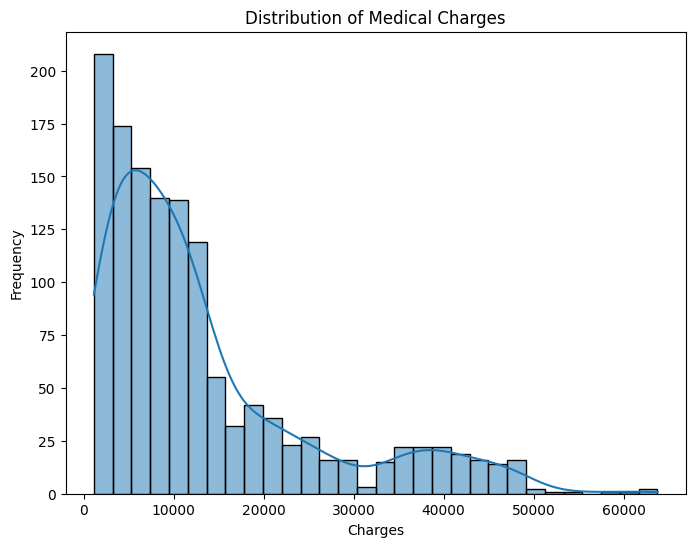

In [6]:
plt.figure(figsize=(8,6))

sns.histplot(df["charges"], bins=30, kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

The distribution of medical charges is right-skewed, indicating that most individuals have relatively low insurance costs, while a smaller group incurs significantly higher expenses. 

The presence of a long tail and extreme values suggests that certain factors may be driving disproportionately high medical costs for specific groups.

**Charge by Smoker Status**

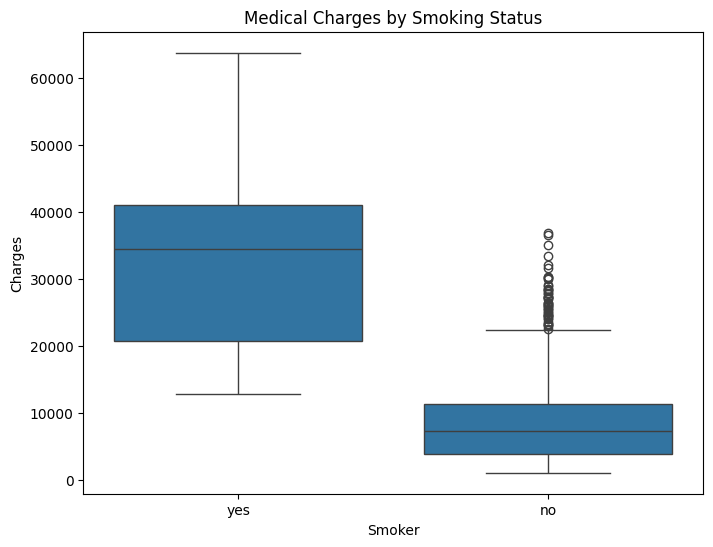

In [7]:
plt.figure(figsize=(8,6))

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Medical Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

- Smokers show a significantly higher median medical cost, around $35,000, compared to non-smokers, whose median remains below $10,000. 

- This indicates that smoking is strongly associated with higher insurance charges.

- Although there are some outliers among non-smokers, which slightly increase the average cost, the majority of this group remains concentrated at lower charge levels.

- In contrast, smokers not only have higher costs on average, but also show a wider distribution, contributing to the high-cost cases observed in the dataset.

This pattern helps explain the long right tail observed in the distribution of medical charges, suggesting that smokers are a key driver of extreme high-cost cases.

**BMI vs Charges**

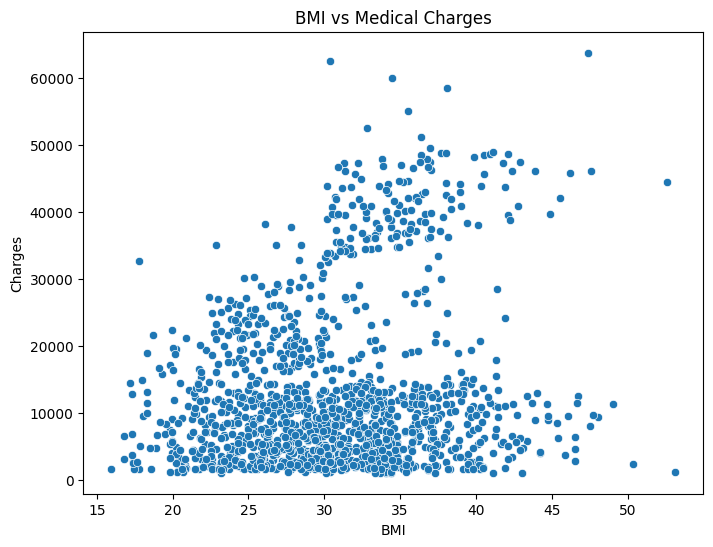

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="bmi", y="charges", data=df)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

- The scatter plot suggests a positive relationship between BMI and medical charges, where higher BMI values tend to be associated with higher costs. However, this relationship appears relatively weak, as the data points are widely scattered and do not follow a clear linear pattern.

- Additionally, the presence of several high-cost observations indicates that other factors may be influencing medical charges beyond BMI alone.

**BMI vs Charges (colored by smoker)**

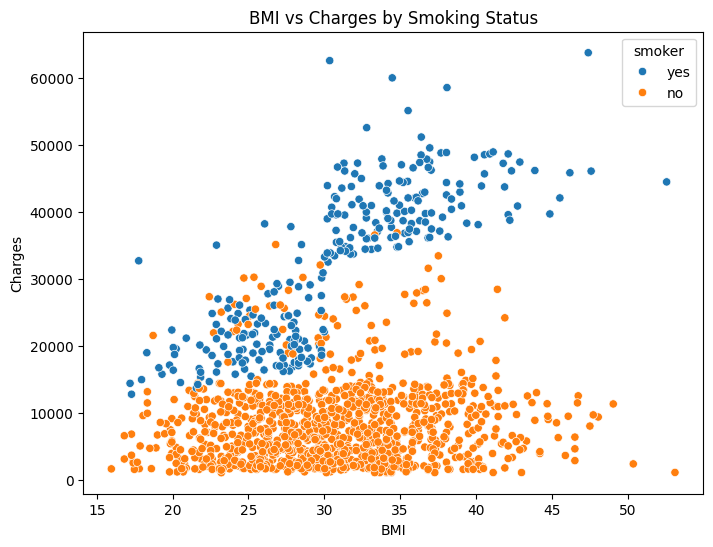

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=df
)

plt.title("BMI vs Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

- When separating the data by smoking status, a much clearer pattern emerges.

- The group of smokers reveals a strong positive relationship between BMI and medical charges, which was not clearly visible in the previous plot. This indicates that the apparent “invisible trend” is largely driven by smokers.

- Additionally, smokers account for most of the high-cost outliers in the dataset, suggesting that smoking significantly amplifies the impact of BMI on medical expenses.

- In contrast, non-smokers show a weaker relationship between BMI and charges, with costs remaining relatively lower and more concentrated.

**Age vs Charges**

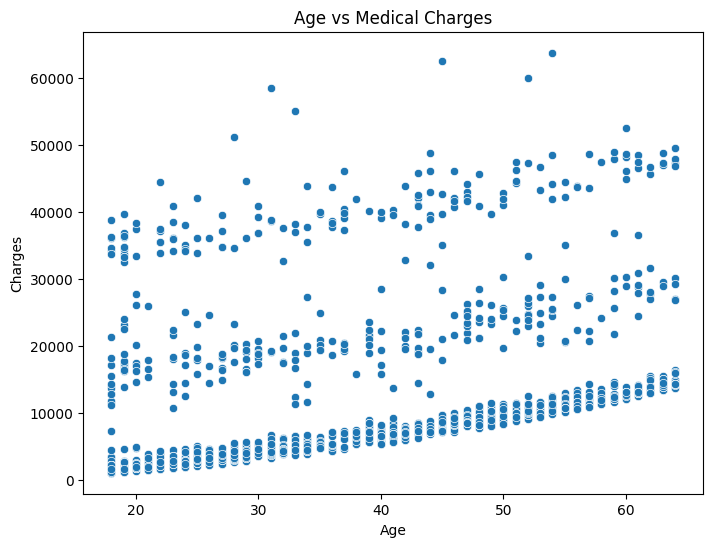

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="age", y="charges", data=df)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

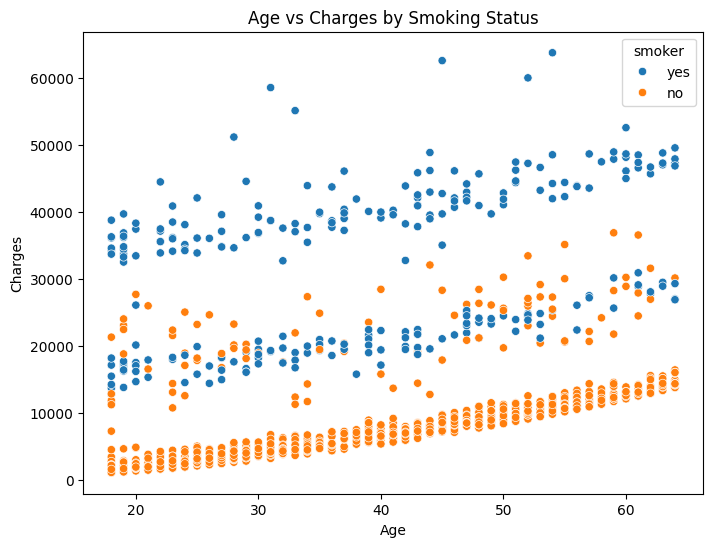

In [ ]:
#Colored by smoker status

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="age",
    y="charges",
    hue="smoker",
    data=df
)

plt.title("Age vs Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

- Smokers consistently exhibit significantly higher costs, often exceeding $30,000, regardless of age. Notably, even younger smokers show elevated medical expenses compared to non-smokers.

- While age shows a positive relationship with charges in both groups, the effect of smoking is substantially stronger, indicating that smoking amplifies medical costs across all age ranges.

This pattern reinforces the idea that smoking not only increases baseline medical costs but also amplifies the effect of other variables such as age.

#### **Key Findings**

- Medical charges are highly right-skewed, with a small group responsible for very high costs  

- Smoking is the most significant factor, with smokers consistently incurring much higher expenses  

- Age is positively associated with charges, with costs increasing over time  

- BMI alone shows a weak relationship, but its effect becomes stronger among smokers  

Overall, the results suggest that smoking is the primary driver of high medical costs, amplifying the impact of other factors such as age and BMI.

---

## Machine Learning

#### Objective

Predict medical charges based on demographic and lifestyle factors

**Data Preparation for ML**

In [12]:
# Select relevant features
df_ml = df.copy()

# Remove missing values (just in case)
df_ml = df_ml.dropna()

df_ml.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Encoding**

In [ ]:
# Convert categorical variables into numeric format
# ML models cannot work with text data
df_ml_encoded = pd.get_dummies(
    df_ml,
    drop_first=True,
    dtype=int   # force 0 and 1
)
df_ml_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


(True = 1,
False = 0)


In [15]:
# Features (inputs)
X = df_ml_encoded.drop(columns=["charges"])

# Target (what we want to predict)
y = df_ml_encoded["charges"]

**Train/Test Split**

In [16]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
X_train.shape, X_test.shape

((1070, 8), (268, 8))

### **Linear Regression**

In [18]:
from sklearn.linear_model import LinearRegression

# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# Predict on test data
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error

# Calculate error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 4181.19


Linear models capture general trends but struggle with non-linear patterns and interactions present in the data

- The Mean Absolute Error (MAE) of 4181 indicates that, on average, the model's predictions differ from actual medical charges by about $4,000.

- While the model captures general trends, its performance is limited by the presence of non-linear relationships and strong interaction effects, particularly related to smoking status.

In [21]:
# Get coefficients
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", ascending=False)

coefficients

,feature,coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


**Model Interpretation**

The Linear Regression coefficients provide insight into how each variable impacts medical charges:

- Smoking status is the most significant factor, increasing costs by approximately $23,600 on average  
- BMI and age both have positive relationships with charges, contributing to higher costs as they increase  
- The number of children has a smaller positive effect  
- Gender and region show minimal impact on medical expenses  

These results are consistent with the exploratory analysis, confirming that smoking is the primary driver of high medical costs, while age and BMI also play important roles.

---

#### **Random Forest Regressor**

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
# Predict on test data
rf_pred = rf_model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error

rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest MAE:", round(rf_mae, 2))

Random Forest MAE: 2550.08


**Model Comparison**

The Random Forest model significantly outperformed the Linear Regression model.

- Linear Regression MAE: ~$4,181  
- Random Forest MAE: ~$2,550  

This represents a substantial improvement in prediction accuracy.

The results suggest that medical charges are influenced by non-linear relationships and interaction effects, particularly related to smoking status. While Linear Regression captures general trends, Random Forest is better suited to model the complexity of the data.

Overall, the Random Forest model provides more accurate predictions by capturing patterns that linear models cannot.

In [25]:
feature_importance_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_rf

,feature,importance
4,smoker_yes,0.608618
1,bmi,0.216506
0,age,0.134232
2,children,0.019413
3,sex_male,0.006379
5,region_northwest,0.005587
6,region_southeast,0.005314
7,region_southwest,0.003950


**Random Forest Feature Importance**

- Smoking status is by far the most important variable, accounting for over 60% of the model's predictive power  
- BMI and age also play significant roles, contributing to higher costs as they increase  
- Other variables such as number of children, gender, and region have minimal impact  

These results strongly reinforce the findings from the exploratory analysis, confirming that smoking is the primary driver of high medical costs, with BMI and age acting as secondary factors.

---

### **Final Conclusion**

The analysis shows that medical insurance charges are highly skewed, with a small group incurring significantly higher costs.

Smoking is the primary driver of these high expenses, while BMI and age also contribute, especially when combined with smoking. 

The Random Forest model outperformed Linear Regression, confirming the presence of non-linear relationships in the data.

Overall, the results highlight the strong impact of lifestyle factors on medical costs and demonstrate the value of combining exploratory analysis with machine learning.